# Assignment 1.1 ML Tools, Process, and Your Learnings

For the following questions, each group must submit one document (.pdf file) but every member must explicitly state their own answer per item. The submission document is basically just a compilation of your individual answers. 10 points per item.

1. Summarize the following:
- What is overfitting and underfitting? Provide examples.
- Define cross fold validation. How is it useful?
2. Demonstrate data splitting for training and testing data. Using any preprocessing library in Python on the iris dataset provided in the module.
3. Provide a sample confusion matrix and demonstrate the computation of TP, FP, FN, TN. How can we derive accuracy of the model based on the previously mentioned metrics?

1. Summarize the following:

What is overfitting and underfitting? Provide examples.
- Underfitting is defined as having low accuracies when training and testing a set of data.
It oversimplifies the data too much, ignoring the patterns in the dataset.
For instance,
- On the other hand, overfitting is defined as having a high training accuracy and low testing accuracy.
It memorizes the training data too much that it cannot perform well when new data is introduced.
An example of this is

Define cross fold validation. How is it useful?
- Cross fold validation is defines as a resampling method when evaluating machine learning models with limited data samples. It ensures that  a predictive model will perform well in practice. It is useful when dealing with a small dataset and avoid it from making the dataset to be underfitting or overfitting.

2. Demonstrate data splitting for training and testing data. Using any preprocessing library in Python on the iris dataset provided in the module.

In [17]:
# Data preprocessing
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = df_species = pd.Series(iris.target).map({0:'setosa', 1:'versicolor', 2:'virginica'})

print(f"Collected {df.shape[0]} samples with {df.shape[1]-1} features each.")
df.head()

Collected 150 samples with 4 features each.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [18]:
# Data splitting
from sklearn.model_selection import train_test_split

X = df[iris.feature_names]
y = pd.Series(iris.target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 105
Testing samples:  45


- The following code shows how data splitting is made using sklearn. We can see that by calling the train_test_split function and indicating the test size, we are able to split the dataset into training and testing data easily. This will be useful in the subsequent steps as it affects the results of model training.

In [19]:
# Model training
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model has been trained on the training data.")

Model has been trained on the training data.


In [20]:
# Evaluation
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Test Accuracy: {accuracy:.2%}")

Test Accuracy: 97.78%


3. Provide a sample confusion matrix and demonstrate the computation of TP, FP, FN, TN. How can we derive accuracy of the model based on the previously mentioned metrics?

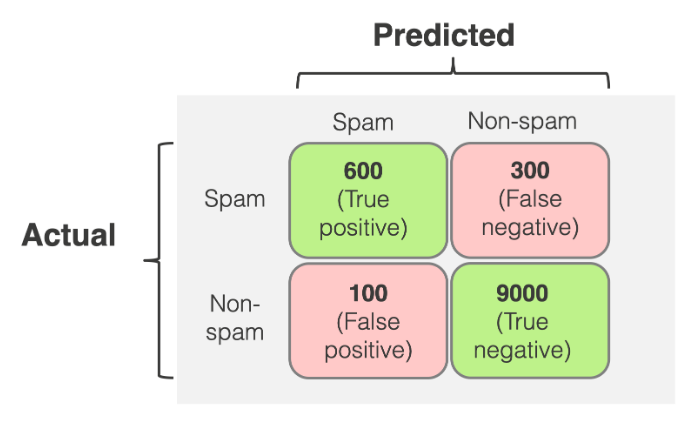

The sample confusion matrix show that:
- TP = 600
- FP = 100
- FN = 300
- TN = 9000



Actual no = 600 + 300 = 900<br>
Actual yes = 100 + 9000 = 9100

True Positive Rate<br>
TP/actual yes = 600 / 9100 = 0.0659

False Positive Rate<br>
FP/actual no = 100 / 9100 = 0.0110

True Negative Rate<br>
TN/actual no = 9000 / 900 = 10

- The model accuracy can derive the TPR, FPR, and TNR by using them for testing depending on the current state of the predictive model. TPR is used when missing a positive case is critical, FPR is used when false positives are very costly and lead to wasted resources, and TNR is used when you need to identify normal cases with high certainty.